# PROG8431 - Data Analysis
## Group 5 Assignment 1

###Team Members
- Juan Antonio Sainz Galvez 9072844
- Asangika Hettiarachchi 7461502

** Dataset:** Ontario Residential Property Data
#https://www.kaggle.com/datasets/mnabaee/ontarioproperties
#Change the name of the dataset to "properties.csv"

## Challenge 1 - Research area and plan to establish a question.
### Field of Inquiry
Ontario Residential Real Estate Market
### Research Question
What patterns can be identified in Ontario residential property prices using descriptive statistics and data visualizations?

### Use Case
This project explores Ontario residential property data to understand price distribution and variation. We use mean, median, and mode to examine typical prices, variance and standard deviation to measure dispersion, and visualizations to identify price distribution, outliers, geographic patterns, and relationships within the dataset.

### Question to consider from slide 20
**Will it be one-time or ongoing?**
Yes will be ongoing if we have more tasks to do with this data. But could be one-time assignemt, too, if we dont use it anymore. 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

print("Ready Professor")

Ready Professor


In [45]:
#Load dataset
data_path = "data/properties.csv"
df = pd.read_csv(data_path)
df = df[df["Price ($)"] > 100000].copy()  # Filter out properties with non-positive prices and create a copy of the DataFrame

df.head()

,Unnamed: 0,Address,AreaName,Price ($),lat,lng
0,0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,6,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


In [46]:
# Understand the structure of the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Dataset shape: (22673, 6)

Column names:
['Unnamed: 0', 'Address', 'AreaName', 'Price ($)', 'lat', 'lng']

Data types:
Unnamed: 0      int64
Address           str
AreaName          str
Price ($)       int64
lat           float64
lng           float64
dtype: object


In [47]:
# Check data quality and missing values
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
Unnamed: 0      0
Address         0
AreaName      399
Price ($)       0
lat             0
lng             0
dtype: int64

Duplicate rows:
0


### Findings
The dataset contains 23,807 records, no duplicate found, above 50k.
The 'AreaName' column contains 480 missing values.

## Understanding the collected data
Dataset with 23,807 residential property records from Ontario above 50k, with price, address, lat and lng.

## Encapsulating code in classes and methods

In [48]:
class PropertyData:

    def __init__(self,data):
        self.data = data

    def show_data(self):
        return self.data.head()

    def dataset_shape(self):
        return self.data.shape

property_data = PropertyData(df)

print("Dataset shape:", property_data.dataset_shape())
property_data.show_data()

Dataset shape: (22673, 6)


,Unnamed: 0,Address,AreaName,Price ($),lat,lng
0,0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,6,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


## 50 word use case
This assignment examines Ontario property prices using descriptive statistics and visualizations. Mean, median, and moed describe typical prices, while standard deviation measures price variation. The histogram shows price distribution, the box plot highlights outliers, the scatter plot displays geographic patterns, and the Venn diagram compares Toronto properties with above-median prices.

## Mean, Median and Mode

In [49]:
mean_price = df["Price ($)"].mean()
median_price = df["Price ($)"].median()
mode_price = df["Price ($)"].mode()[0]

print(f"Mean Price: ${mean_price:.2f}")
print(f"Median Price: ${median_price:.2f}")
print(f"Mode Price: ${mode_price:.2f}")



Mean Price: $626221.13
Median Price: $407500.00
Mode Price: $299900.00


## Variance, Standard Deviation, and Quartiles

In [50]:
variance_price = df["Price ($)"].var()
std_price = df["Price ($)"].std()

quartiles = df["Price ($)"].quantile([0.25, 0.5, 0.75, 1.00])

print(f"Variance of Price: ${variance_price:.2f}")
print(f"Standard Deviation: ${std_price:.2f}")

print("Quartiles:")
print(quartiles)

Variance of Price: $767110020522.08
Standard Deviation: $875848.17
Quartiles:
0.25      273999.0
0.50      407500.0
0.75      659000.0
1.00    32500000.0
Name: Price ($), dtype: float64


### Scatter Plot

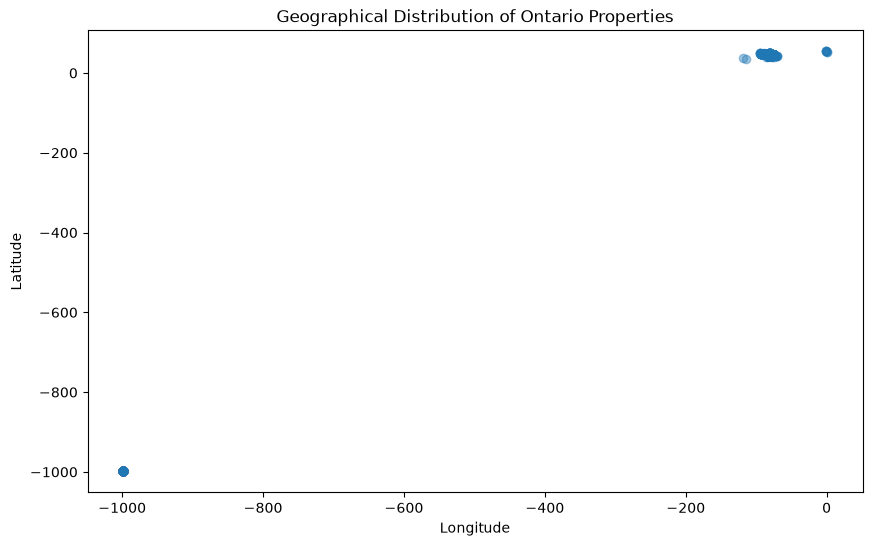

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["lng"],
    df["lat"],
    alpha=0.4       
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Ontario Properties")

plt.show()

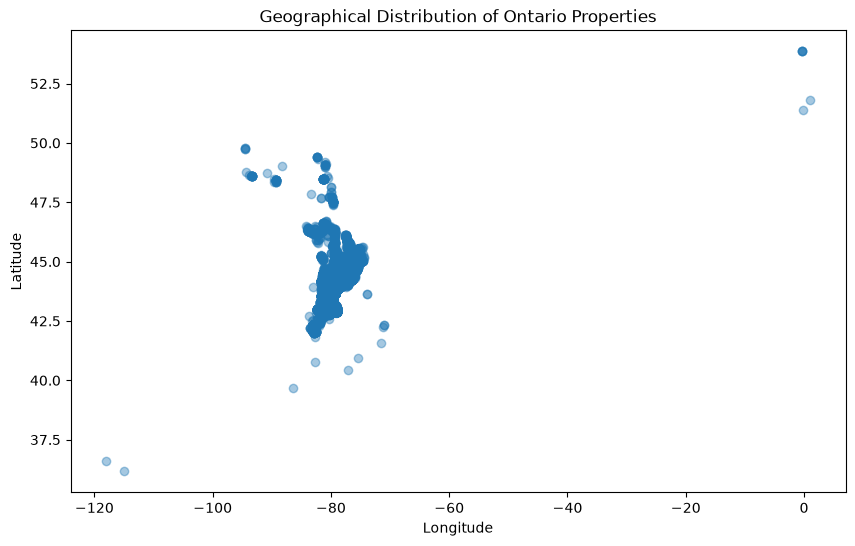

In [52]:
# Keep only valid geographic coordinates for the scatter plot
valid_coordinates = df[
    df["lat"].between(-90, 90) &
    df["lng"].between(-180, 180)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    valid_coordinates["lng"],
    valid_coordinates["lat"],
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Ontario Properties")

plt.show()

### Histogram

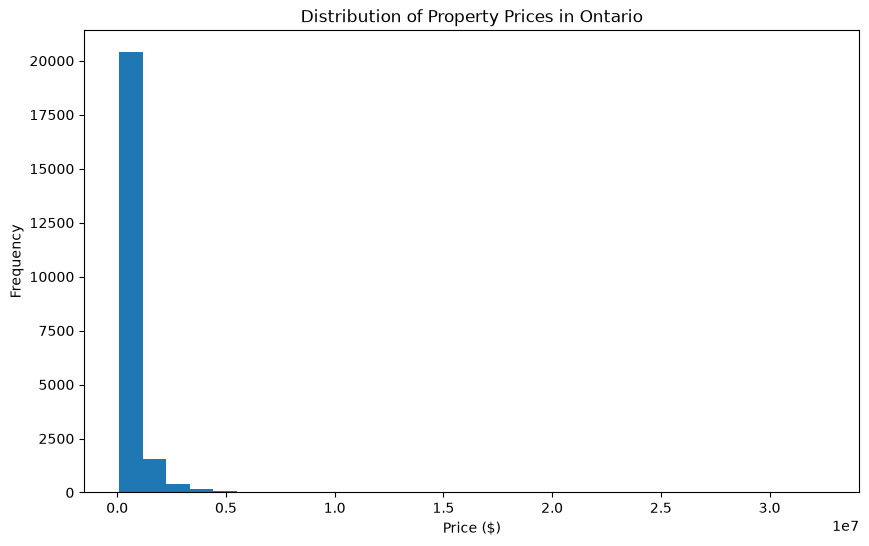

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Price ($)"], bins=30)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Prices in Ontario")
plt.show()



Graph showing data between 100,000k CAD and 2,000,000 CAD

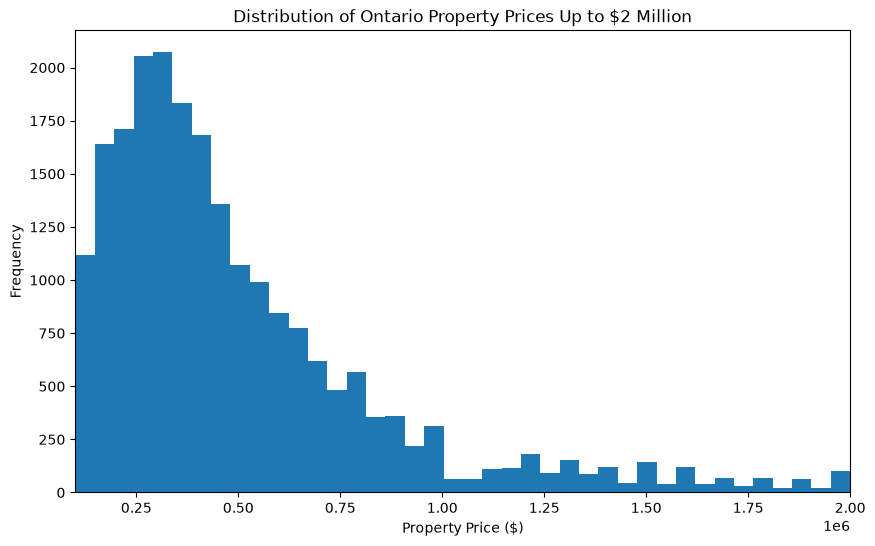

In [59]:
histogram_data = df[
    (df["Price ($)"] > 100000) &
    (df["Price ($)"] <= 2000000)
]

plt.figure(figsize=(10, 6))

plt.hist(histogram_data["Price ($)"], bins=40)

plt.xlabel("Property Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Ontario Property Prices Up to $2 Million")

plt.xlim(100000, 2000000)

plt.show()

### Box and Whisker Plot

C:\Users\anton\AppData\Local\Temp\ipykernel_26548\2307677261.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price ($)"], vert=False)


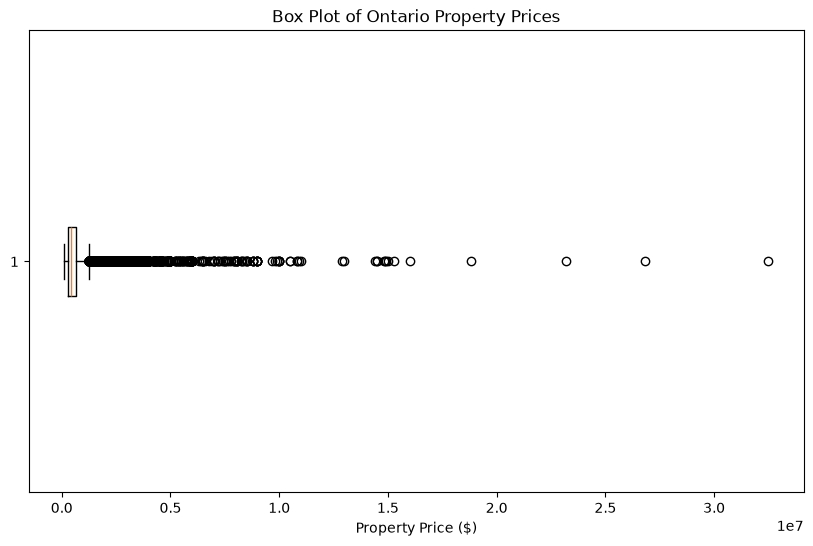

In [54]:
plt.figure(figsize=(10, 6))

plt.boxplot(df["Price ($)"], vert=False)

plt.xlabel("Property Price ($)")
plt.title("Box Plot of Ontario Property Prices")

plt.show()

Same issue with the graph before, showing properties above 2million Canadian dollar.

C:\Users\anton\AppData\Local\Temp\ipykernel_26548\3673150952.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(boxplot_data, vert=False)


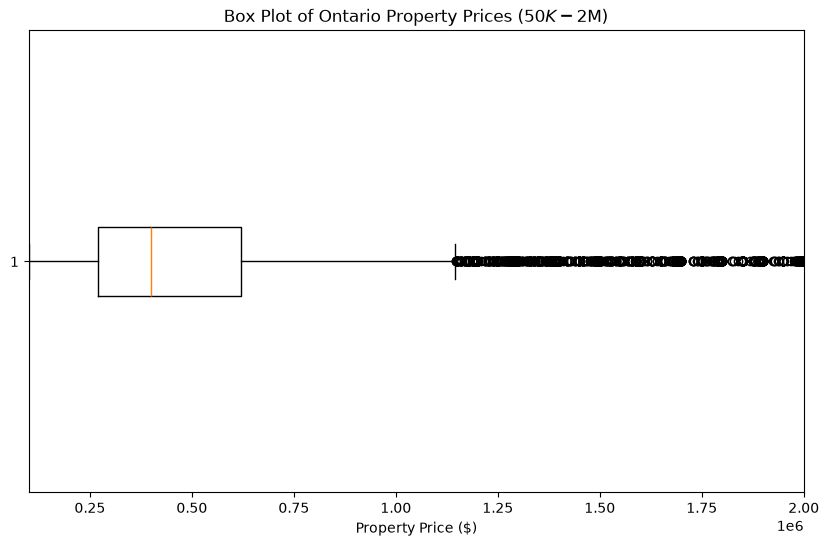

In [60]:
# Focus the box plot on properties between $50,000 and $2 million
boxplot_data = df[
    (df["Price ($)"] > 100000) &
    (df["Price ($)"] <= 2000000)
]["Price ($)"]

plt.figure(figsize=(10, 6))

plt.boxplot(boxplot_data, vert=False)

plt.xlabel("Property Price ($)")
plt.title("Box Plot of Ontario Property Prices ($50K - $2M)")

plt.xlim(100000, 2000000)

plt.show()

In [55]:
### Venn Diagram


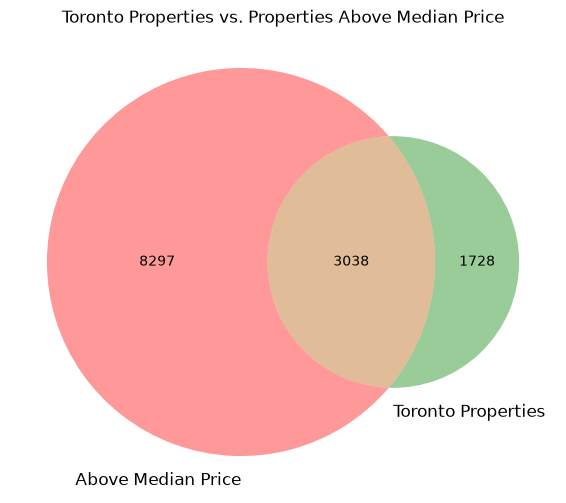

In [56]:
above_median = set(df[df["Price ($)"] > median_price].index)

toronto = set(
    df[df["Address"].str.contains("Toronto", case=False, na=False)].index
)

plt.figure(figsize=(8, 6))

venn2(
    [above_median, toronto],
    set_labels=("Above Median Price", "Toronto Properties")
)

plt.title("Toronto Properties vs. Properties Above Median Price")
plt.show()

### Summary

In [57]:
price_summary = df["Price ($)"].describe()

price_summary

count    2.267300e+04
mean     6.262211e+05
std      8.758482e+05
min      1.010000e+05
25%      2.739990e+05
50%      4.075000e+05
75%      6.590000e+05
max      3.250000e+07
Name: Price ($), dtype: float64